In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Install the library to read .xes files
!pip install pm4py

import pm4py

# 2. Define the exact file path
path = '/content/drive/MyDrive/Proyecto PM/BPI_Challenge_2012.xes'

# 3. Load the file
log = pm4py.read_xes(path)

# 4. Preview first events to confirm successful load
print(f"Success! The file contains {len(log)} cases.")
print(log.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

Success! The file contains 262200 cases.
  org:resource lifecycle:transition            concept:name  \
0          112             COMPLETE             A_SUBMITTED   
1          112             COMPLETE       A_PARTLYSUBMITTED   
2          112             COMPLETE           A_PREACCEPTED   
3          112             SCHEDULE  W_Completeren aanvraag   
4          NaN                START  W_Completeren aanvraag   

                    time:timestamp                    case:REG_DATE  \
0 2011-10-01 00:38:44.546000+00:00 2011-10-01 00:38:44.546000+00:00   
1 2011-10-01 00:38:44.880000+00:00 2011-10-01 00:38:44.546000+00:00   
2 2011-10-01 00:39:37.906000+00:00 2011-10-01 00:38:44.546000+00:00   
3 2011-10-01 00:39:38.875000+00:00 2011-10-01 00:38:44.546000+00:00   
4 2011-10-01 11:36:46.437000+00:00 2011-10-01 00:38:44.546000+00:00   

  case:concept:name case:AMOUNT_REQ  
0            173688           20000  
1            173688           20000  
2            173688           20000  
3

In [3]:
print(f"✅ File loaded")
print(f"   Total events  : {len(log):,}")
print(f"   Unique cases  : {log['case:concept:name'].nunique():,}")
print(f"   Columns      : {list(log.columns)}")

✅ File loaded
   Total events  : 262,200
   Unique cases  : 13,087
   Columns      : ['org:resource', 'lifecycle:transition', 'concept:name', 'time:timestamp', 'case:REG_DATE', 'case:concept:name', 'case:AMOUNT_REQ']


In [4]:
print("FIRST ROWS")
print(log.head())

print("\n DATA TYPES")
print(log.dtypes)

print("\n UNIQUE ACTIVITIES")
for act in sorted(log['concept:name'].unique()):
    print(f"  {act}")

print("\n TRANSITION TYPES")
print(log['lifecycle:transition'].value_counts())

FIRST ROWS
  org:resource lifecycle:transition            concept:name  \
0          112             COMPLETE             A_SUBMITTED   
1          112             COMPLETE       A_PARTLYSUBMITTED   
2          112             COMPLETE           A_PREACCEPTED   
3          112             SCHEDULE  W_Completeren aanvraag   
4          NaN                START  W_Completeren aanvraag   

                    time:timestamp                    case:REG_DATE  \
0 2011-10-01 00:38:44.546000+00:00 2011-10-01 00:38:44.546000+00:00   
1 2011-10-01 00:38:44.880000+00:00 2011-10-01 00:38:44.546000+00:00   
2 2011-10-01 00:39:37.906000+00:00 2011-10-01 00:38:44.546000+00:00   
3 2011-10-01 00:39:38.875000+00:00 2011-10-01 00:38:44.546000+00:00   
4 2011-10-01 11:36:46.437000+00:00 2011-10-01 00:38:44.546000+00:00   

  case:concept:name case:AMOUNT_REQ  
0            173688           20000  
1            173688           20000  
2            173688           20000  
3            173688           2

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [6]:
df = pm4py.convert_to_dataframe(log)

df.head()

,org:resource,lifecycle:transition,concept:name,time:timestamp,case:REG_DATE,case:concept:name,case:AMOUNT_REQ
0,112,COMPLETE,A_SUBMITTED,2011-10-01 00:38:44.546000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
1,112,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
2,112,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
3,112,SCHEDULE,W_Completeren aanvraag,2011-10-01 00:39:38.875000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000


In [7]:
df = log[log['lifecycle:transition'] == 'COMPLETE'].copy()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164506 entries, 0 to 262199
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   org:resource          156364 non-null  object             
 1   lifecycle:transition  164506 non-null  object             
 2   concept:name          164506 non-null  object             
 3   time:timestamp        164506 non-null  datetime64[ns, UTC]
 4   case:REG_DATE         164506 non-null  datetime64[ns, UTC]
 5   case:concept:name     164506 non-null  object             
 6   case:AMOUNT_REQ       164506 non-null  object             
dtypes: datetime64[ns, UTC](2), object(5)
memory usage: 10.0+ MB


In [9]:
df = df.rename(columns={
    "case:concept:name":"case_id",
    "concept:name":"activity",
    "time:timestamp":"timestamp",
    "org:resource":"resource",
    "case:AMOUNT_REQ":"amount",
    "case:REG_DATE":"reg_date"
})

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164506 entries, 0 to 262199
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   resource              156364 non-null  object             
 1   lifecycle:transition  164506 non-null  object             
 2   activity              164506 non-null  object             
 3   timestamp             164506 non-null  datetime64[ns, UTC]
 4   reg_date              164506 non-null  datetime64[ns, UTC]
 5   case_id               164506 non-null  object             
 6   amount                164506 non-null  object             
dtypes: datetime64[ns, UTC](2), object(5)
memory usage: 10.0+ MB


In [11]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

In [12]:
print(f"   Total events  : {len(df):,}")
print(f"   Unique cases  : {df['case_id'].nunique():,}")
print(f"   Columns       : {list(df.columns)}")
print(f"   Activities    : {df['activity'].nunique():,}")

   Total events  : 164,506
   Unique cases  : 13,087
   Columns       : ['resource', 'lifecycle:transition', 'activity', 'timestamp', 'reg_date', 'case_id', 'amount']
   Activities    : 23


In [13]:
df = df.sort_values(["case_id","timestamp"]).reset_index(drop=True)

In [14]:
activity_frequency = df["activity"].value_counts()

print(f"Most frequent activities:\n{activity_frequency}")

Most frequent activities:
activity
W_Completeren aanvraag            23967
W_Nabellen offertes               22976
A_SUBMITTED                       13087
A_PARTLYSUBMITTED                 13087
W_Nabellen incomplete dossiers    11407
W_Valideren aanvraag               7895
A_DECLINED                         7635
A_PREACCEPTED                      7367
O_SENT                             7030
O_CREATED                          7030
O_SELECTED                         7030
W_Afhandelen leads                 5898
A_ACCEPTED                         5113
A_FINALIZED                        5015
O_CANCELLED                        3655
O_SENT_BACK                        3454
A_CANCELLED                        2807
A_APPROVED                         2246
A_REGISTERED                       2246
A_ACTIVATED                        2246
O_ACCEPTED                         2243
O_DECLINED                          802
W_Beoordelen fraude                 270
Name: count, dtype: int64


In [15]:
cycle_times = df.groupby("case_id").agg(
    start = ("timestamp", "min"),
    end = ("timestamp", "max")
)

In [16]:
cycle_times["cycle_time_days"] = (cycle_times["end"] - cycle_times["start"]).dt.total_seconds() / 86400

In [17]:
print("CYCLE TIME ANALYSIS PER CASE (days)")
print(cycle_times['cycle_time_days'].describe().round(2))

CYCLE TIME ANALYSIS PER CASE (days)
count    13087.00
mean         8.61
std         12.07
min          0.00
25%          0.00
50%          0.81
75%         14.19
max         91.41
Name: cycle_time_days, dtype: float64


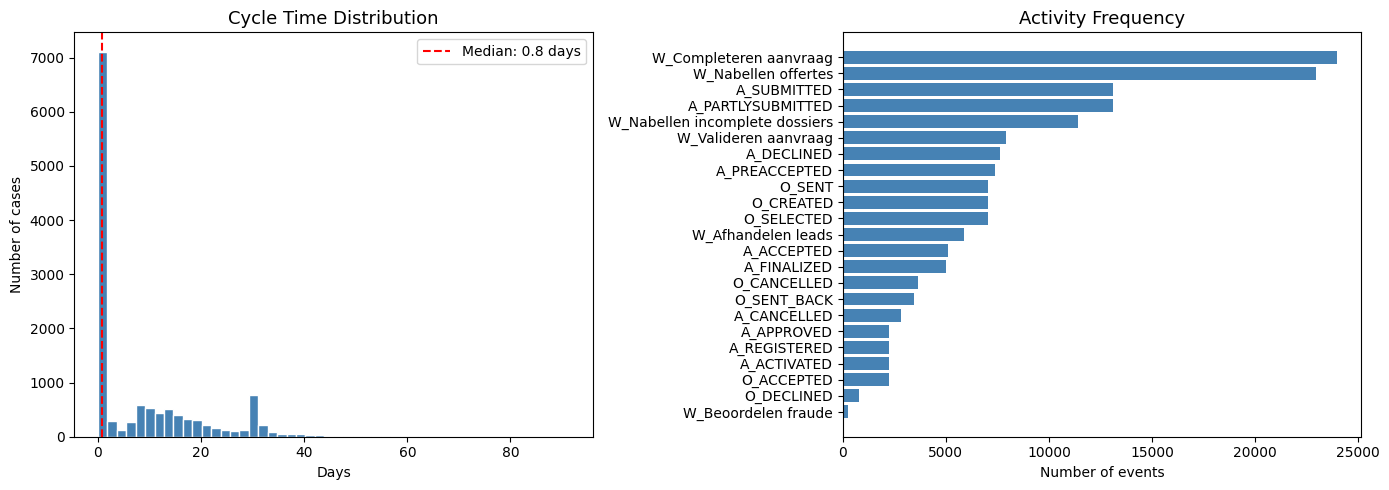

In [18]:
fig, axes = plt.subplots(1,2,figsize=(14, 5))

axes[0].hist(
    cycle_times['cycle_time_days'],
    bins=50, color='steelblue', edgecolor='white'
)

axes[0].set_title('Cycle Time Distribution', fontsize=13)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of cases')
axes[0].axvline(
    cycle_times['cycle_time_days'].median(),
    color='red', linestyle='--', label=f"Median: {cycle_times['cycle_time_days'].median():.1f} days"
)
axes[0].legend()

act_counts = df['activity'].value_counts()
axes[1].barh(act_counts.index, act_counts.values, color='steelblue')
axes[1].set_title('Activity Frequency', fontsize=13)
axes[1].set_xlabel('Number of events')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('phase1_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
variants = df.groupby('case_id')['activity'].apply(list)

In [20]:
variants = variants.apply(lambda x: " -> ".join(x))

In [21]:
variant_counts = variants.value_counts()

variant_counts.head(10)

,count
activity,
A_SUBMITTED -> A_PARTLYSUBMITTED -> A_DECLINED,3429
A_SUBMITTED -> A_PARTLYSUBMITTED -> A_DECLINED -> W_Afhandelen leads,1872
A_SUBMITTED -> A_PARTLYSUBMITTED -> W_Afhandelen leads -> A_DECLINED -> W_Afhandelen leads,271
A_SUBMITTED -> A_PARTLYSUBMITTED -> A_PREACCEPTED -> W_Afhandelen leads -> A_DECLINED -> W_Completeren aanvraag,209
A_SUBMITTED -> A_PARTLYSUBMITTED -> A_PREACCEPTED -> A_DECLINED -> W_Completeren aanvraag,160
A_SUBMITTED -> A_PARTLYSUBMITTED -> A_PREACCEPTED -> A_CANCELLED -> W_Completeren aanvraag,134
A_SUBMITTED -> A_PARTLYSUBMITTED -> A_PREACCEPTED -> W_Afhandelen leads -> W_Completeren aanvraag -> A_DECLINED -> W_Completeren aanvraag,126
A_SUBMITTED -> A_PARTLYSUBMITTED -> A_PREACCEPTED -> W_Completeren aanvraag -> A_DECLINED -> W_Completeren aanvraag,93
A_SUBMITTED -> A_PARTLYSUBMITTED -> A_PREACCEPTED -> W_Completeren aanvraag -> A_CANCELLED -> W_Completeren aanvraag,89


In [22]:
print(f"Total variants: {len(variant_counts):,}")

Total variants: 4,336


In [23]:
# Calculate trace length per case

trace_length = df.groupby('case_id')['activity'].size()

trace_length = trace_length[trace_length > 1]

print(trace_length.head(10))

case_id
173688    18
173691    26
173694    37
173697     3
173700     3
173703     6
173706     8
173709     8
173712     8
173715    16
Name: activity, dtype: int64


In [24]:
df["previous_time"] = df.groupby("case_id")["timestamp"].shift()

df['waiting_time'] = df['timestamp'] - df['previous_time']

In [25]:
df[["case_id", "activity", "waiting_time"]].head(10)

,case_id,activity,waiting_time
0,173688,A_SUBMITTED,NaT
1,173688,A_PARTLYSUBMITTED,0 days 00:00:00.334000
2,173688,A_PREACCEPTED,0 days 00:00:53.026000
3,173688,A_ACCEPTED,0 days 11:03:05.402000
4,173688,O_SELECTED,0 days 00:02:25.935000
5,173688,A_FINALIZED,0 days 00:00:00
6,173688,O_CREATED,0 days 00:00:01.954000
7,173688,O_SENT,0 days 00:00:00.183000
8,173688,W_Completeren aanvraag,0 days 00:00:02.537000
9,173688,W_Nabellen offertes,0 days 00:31:55.007000


In [26]:
# Identify bottlenecks: top 10 activities with the highest average waiting time


bottlenecks = df.groupby('activity')['waiting_time'].mean()

bottlenecks.sort_values(ascending=False).head(10)

,waiting_time
activity,
O_SENT_BACK,3 days 18:37:24.038866821
W_Nabellen offertes,2 days 07:26:59.857003481
A_CANCELLED,1 days 02:56:02.476635910
O_CANCELLED,0 days 23:14:44.104500410
W_Valideren aanvraag,0 days 20:16:37.971340215
W_Completeren aanvraag,0 days 19:12:02.454690073
O_DECLINED,0 days 18:58:14.446980049
W_Beoordelen fraude,0 days 14:38:03.635581481
O_ACCEPTED,0 days 13:46:39.767576905


In [27]:
df.to_csv("event_log_clean.csv", index=False)

In [28]:
variant_counts.to_csv("process_variants.csv")

In [29]:
cycle_times.reset_index().to_csv("cycle_times.csv", index=False)

In [30]:
import pandas as pd
import sqlite3

In [31]:
df_events = pd.read_csv('event_log_clean.csv', parse_dates=['timestamp'])
df_cycles = pd.read_csv('cycle_times.csv', parse_dates=['start', 'end'])

print(f"Loaded events:       {len(df_events):,}")
print(f"Cases (cycle times): {len(df_cycles):,}")

Loaded events:       164,506
Cases (cycle times): 13,087


In [32]:
conn = sqlite3.connect('bpi2012.db')

df_events.to_sql('events', conn, if_exists='replace', index=False)
df_cycles.to_sql('cycle_times', conn, if_exists='replace', index=False)

13087

In [33]:
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM events")
print(f"\n Rows in event:  {cursor.fetchone()[0]:,}")
cursor.execute("SELECT COUNT(*) FROM cycle_times")
print(f"\n Rows in cycle times: {cursor.fetchone()[0]:,}")


 Rows in event:  164,506

 Rows in cycle times: 13,087


In [34]:
query_overview = """
SELECT
  COUNT (*) AS total_events,
  COUNT(DISTINCT case_id) AS total_cases,
  COUNT(DISTINCT activity) AS total_activities
FROM events
"""

df_overview = pd.read_sql(query_overview, conn)
print('Process Overview')
print(df_overview.to_string(index=False))

Process Overview
 total_events  total_cases  total_activities
       164506        13087                23


In [35]:
query_freq = """
SELECT
    activity,
    COUNT (*) as total_events,
    ROUND(COUNT (*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM events
GROUP BY activity
ORDER BY total_events DESC
"""

df_freq = pd.read_sql(query_freq, conn)
print("Activity Frequency")
print(df_freq.to_string(index=False))

Activity Frequency
                      activity  total_events  pct
        W_Completeren aanvraag         23967 14.6
           W_Nabellen offertes         22976 14.0
             A_PARTLYSUBMITTED         13087  8.0
                   A_SUBMITTED         13087  8.0
W_Nabellen incomplete dossiers         11407  6.9
          W_Valideren aanvraag          7895  4.8
                    A_DECLINED          7635  4.6
                 A_PREACCEPTED          7367  4.5
                     O_CREATED          7030  4.3
                    O_SELECTED          7030  4.3
                        O_SENT          7030  4.3
            W_Afhandelen leads          5898  3.6
                    A_ACCEPTED          5113  3.1
                   A_FINALIZED          5015  3.0
                   O_CANCELLED          3655  2.2
                   O_SENT_BACK          3454  2.1
                   A_CANCELLED          2807  1.7
                   A_ACTIVATED          2246  1.4
                    A_APPROVED 

In [36]:
query_start = """
SELECT activity, COUNT (*) as cases
FROM (
    SELECT case_id, activity,
    ROW_NUMBER() OVER(PARTITION BY case_id ORDER BY timestamp) AS rn
    FROM events
)
WHERE rn = 1
GROUP BY activity
ORDER BY cases DESC
"""
query_end = """
SELECT activity, COUNT (*) as cases
FROM (
    SELECT case_id, activity,
    ROW_NUMBER() OVER(PARTITION BY case_id ORDER BY timestamp DESC) AS rn
    FROM events
)
WHERE rn = 1
GROUP BY activity
ORDER BY cases DESC
"""

df_start = pd.read_sql(query_start, conn)
df_end = pd.read_sql(query_end, conn)

print("Initial Activities")
print(df_start.to_string(index=False))

print("Final Activities (outcomes)")
print(df_end.to_string(index=False))

Initial Activities
   activity  cases
A_SUBMITTED  13087
Final Activities (outcomes)
                      activity  cases
                    A_DECLINED   3429
          W_Valideren aanvraag   2749
            W_Afhandelen leads   2234
        W_Completeren aanvraag   1941
           W_Nabellen offertes   1299
                   A_CANCELLED    663
W_Nabellen incomplete dossiers    453
                   O_CANCELLED    261
           W_Beoordelen fraude     57
                    A_APPROVED      1


In [37]:
query_cycle = """
WITH last_event AS (
    SELECT case_id, activity AS final_status
    FROM events
    WHERE (case_id, timestamp) IN (
        SELECT case_id, MAX(timestamp)
        FROM events
        GROUP BY case_id
    )
)
SELECT
    le.final_status,
    COUNT(*) AS total_cases,
    ROUND(AVG(ct.cycle_time_days), 1) AS avg_days,
    ROUND(MIN(ct.cycle_time_days), 1) AS min_days,
    ROUND(MAX(ct.cycle_time_days), 1) AS max_days
FROM last_event le
JOIN cycle_times ct ON le.case_id = ct.case_id
GROUP BY le.final_status
ORDER BY total_cases DESC
"""
df_cycle = pd.read_sql(query_cycle, conn)
print("CYCLE TIME BY FINAL STATUS")
print(df_cycle.to_string(index=False))


CYCLE TIME BY FINAL STATUS
                  final_status  total_cases  avg_days  min_days  max_days
                    A_DECLINED         3429       0.0       0.0       0.0
          W_Valideren aanvraag         2749      16.7       0.0      85.9
            W_Afhandelen leads         2234       0.2       0.0       6.7
        W_Completeren aanvraag         1954       3.1       0.0      32.6
           W_Nabellen offertes         1314      16.5       0.0      82.8
                   A_CANCELLED          924      32.4       0.0      91.4
                   O_CANCELLED          524      34.2       2.5      91.4
W_Nabellen incomplete dossiers          453      20.7       0.2      84.3
           W_Beoordelen fraude           57       2.6       0.0      13.0
                  A_REGISTERED            1      12.9      12.9      12.9
                    A_APPROVED            1      12.9      12.9      12.9
                   A_ACTIVATED            1      12.9      12.9      12.9


In [38]:
query_dist = """
SELECT
    CASE
        WHEN cycle_time_days <= 1  THEN '1. Up to 1 day'
        WHEN cycle_time_days <= 7  THEN '2. 1 to 7 days'
        WHEN cycle_time_days <= 30 THEN '3. 7 to 30 days'
        WHEN cycle_time_days <= 60 THEN '4. 30 to 60 days'
        ELSE                            '5. More than 60 days'
    END AS duration_range,
    COUNT(*) AS cases,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM cycle_times
GROUP BY duration_range
ORDER BY duration_range
"""

df_dist = pd.read_sql(query_dist, conn)
print("=== CASE DISTRIBUTION BY DURATION ===")
print(df_dist.to_string(index=False))

=== CASE DISTRIBUTION BY DURATION ===
      duration_range  cases  pct
      1. Up to 1 day   6788 51.9
      2. 1 to 7 days    921  7.0
     3. 7 to 30 days   3985 30.5
    4. 30 to 60 days   1351 10.3
5. More than 60 days     42  0.3


In [39]:
query_bottleneck = """
WITH waiting_times AS (
    SELECT
      activity,
      JULIANDAY(timestamp) - JULIANDAY(
        LAG(timestamp) OVER (PARTITION BY case_id ORDER BY timestamp)
      ) AS waiting_days
    FROM events
)
SELECT
    activity,
    ROUND(AVG(waiting_days), 2) AS avg_waiting_days
FROM waiting_times
WHERE waiting_days IS NOT NULL
GROUP BY activity
ORDER BY avg_waiting_days DESC
LIMIT 10
"""

df_bottleneck = pd.read_sql(query_bottleneck, conn)
print("TOP 10 Bottlenecks (highest average wait)")
print(df_bottleneck.to_string(index=False))

TOP 10 Bottlenecks (highest average wait)
                      activity  avg_waiting_days
                   O_SENT_BACK              3.78
           W_Nabellen offertes              2.31
                   A_CANCELLED              1.12
                   O_CANCELLED              0.97
          W_Valideren aanvraag              0.84
        W_Completeren aanvraag              0.80
                    O_DECLINED              0.79
           W_Beoordelen fraude              0.61
                    O_ACCEPTED              0.57
W_Nabellen incomplete dossiers              0.54


In [40]:
query_rework_detail = """
SELECT
    activity,
    COUNT (*) AS cases_with_rework,
    ROUND(AVG(repetitions), 1) AS avg_repetitions
FROM (
    SELECT case_id, activity, COUNT(*) AS repetitions
    FROM events
    GROUP BY case_id, activity
    HAVING COUNT(*) > 1
) sub
GROUP BY activity
ORDER BY cases_with_rework DESC
"""

query_rework_rate = """
WITH rework_cases AS(
    SELECT DISTINCT case_id
    FROM events
    GROUP BY case_id, activity
    HAVING COUNT (*) > 1
)
SELECT
    ROUND(
    COUNT(*) * 100 / (SELECT COUNT(DISTINCT case_id) FROM events),
    1
    ) AS rework_rate_pct
FROM rework_cases
"""

df_rework = pd.read_sql(query_rework_detail, conn)
df_rw_rate = pd.read_sql(query_rework_rate, conn)

print('Activities with Rework')
print(df_rework.to_string(index=False))
print(f"\nGLOBAL REWORK RATE : {df_rw_rate['rework_rate_pct'].iloc[0]}%")

Activities with Rework
                      activity  cases_with_rework  avg_repetitions
        W_Completeren aanvraag               4420              4.8
           W_Nabellen offertes               4274              5.2
          W_Valideren aanvraag               2020              3.3
W_Nabellen incomplete dossiers               1474              7.6
                        O_SENT               1438              2.4
                    O_SELECTED               1438              2.4
                     O_CREATED               1438              2.4
            W_Afhandelen leads                772              2.5
                   O_CANCELLED                749              2.3
                   O_SENT_BACK                197              2.0
           W_Beoordelen fraude                 81              3.0

GLOBAL REWORK RATE : 53.0%


In [41]:
query_variants = """
WITH variants AS (
    SELECT
      case_id,
      GROUP_CONCAT(activity, '->') AS variant
    FROM (
      SELECT case_id, activity
      FROM events
      ORDER BY case_id, timestamp
    )
    GROUP BY case_id
)
SELECT
    variant,
    COUNT (*) AS cases,
    ROUND(COUNT(*) * 100 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM variants
GROUP BY variant
ORDER BY cases DESC
"""

df_variants = pd.read_sql(query_variants, conn)

print(f"Total variants: {len(df_variants):,}")
print("TOP 10 VARIANTS")
print(df_variants.head(10).to_string(index=False))

print("HAPPY PATH (Most frequent variant)")
print(df_variants.iloc[0]['variant'])
print(f"Represents {df_variants.iloc[0]['pct']}% of cases")

Total variants: 4,336
TOP 10 VARIANTS
                                                                                                                                              variant  cases  pct
                                                                                                           A_SUBMITTED->A_PARTLYSUBMITTED->A_DECLINED   3429 26.0
                                                                                       A_SUBMITTED->A_PARTLYSUBMITTED->A_DECLINED->W_Afhandelen leads   1872 14.0
                                                                   A_SUBMITTED->A_PARTLYSUBMITTED->W_Afhandelen leads->A_DECLINED->W_Afhandelen leads    271  2.0
                                                A_SUBMITTED->A_PARTLYSUBMITTED->A_PREACCEPTED->W_Afhandelen leads->A_DECLINED->W_Completeren aanvraag    209  1.0
                                                                    A_SUBMITTED->A_PARTLYSUBMITTED->A_PREACCEPTED->A_DECLINED->W_Completeren aanvraag   

In [42]:
df_freq.to_csv('sql_activity_frequency.csv', index=False)
df_cycle.to_csv('sql_cycle_time_by_status.csv', index=False)
df_dist.to_csv('sql_duration_distribution.csv', index=False)
df_rework.to_csv('sql_rework.csv', index=False)
df_rw_rate.to_csv('sql_rework_rate.csv', index=False)
df_variants.to_csv('sql_variants.csv', index=False)
df_overview.to_csv('sql_overview.csv', index=False)
df_bottleneck.to_csv('sql_bottleneck.csv', index=False)
df_start.to_csv('sql_initial_activities.csv', index=False)
df_end.to_csv('sql_final_activities.csv', index=False)

print("✅ Results exported")


✅ Results exported


In [43]:
conn.close()
print("✅ SQLite connection closed")

✅ SQLite connection closed


In [44]:
df['timestamp'] = df['timestamp'].dt.tz_localize(None)

# Verify that it looks correct
print(df['timestamp'].head())
print(df['timestamp'].dtype)

0   2011-10-01 00:38:44.546
1   2011-10-01 00:38:44.880
2   2011-10-01 00:39:37.906
3   2011-10-01 11:42:43.308
4   2011-10-01 11:45:09.243
Name: timestamp, dtype: datetime64[ns]
datetime64[ns]


In [45]:
df.to_csv('event_log_clean.csv', index=False)
print("✅ CSV re-exported without timezone")

✅ CSV re-exported without timezone


In [46]:
# 1. Find columns with 'time' or 'date' in their name and force conversion to datetime
for col in df.columns:
    if 'time' in col.lower() or 'date' in col.lower():
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 2. Remove the timezone from ALL detected datetime columns
for col in df.select_dtypes(include=['datetimetz']).columns:
    df[col] = df[col].dt.tz_localize(None)

# 3. Re-export the clean dataset
df.to_csv('event_log_clean.csv', index=False)
print("✅ All date/time columns corrected and exported successfully!")


✅ All date/time columns corrected and exported successfully!
